In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded")

All libraries loaded


In [2]:
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','attack_type','difficulty'
]

print(f"Total columns defined: {len(columns)}")

Total columns defined: 43


In [3]:
train_df = pd.read_csv('../data/KDDTrain+.txt', names=columns)
test_df  = pd.read_csv('../data/KDDTest+.txt',  names=columns)

# Drop difficulty column (not a feature)
train_df.drop('difficulty', axis=1, inplace=True)
test_df.drop('difficulty', axis=1, inplace=True)

print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)
train_df.head(3)

Train shape: (125973, 42)
Test shape:  (22544, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.0,0.0,0.0,0.05,0.0,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.0,0.0,0.0,0.00,0.0,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.0,1.0,1.0,0.00,0.0,neptune


Attack type distribution (train):
attack_type
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


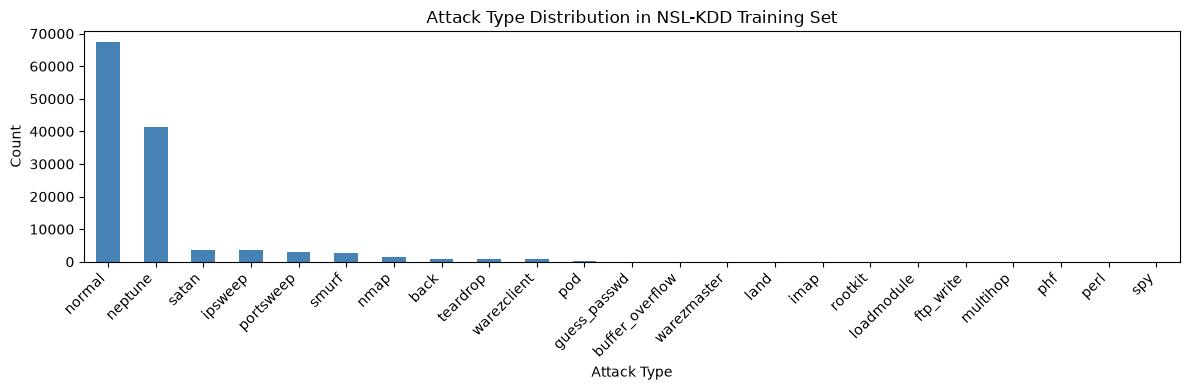

Plot saved to results/


In [4]:
print("Attack type distribution (train):")
print(train_df['attack_type'].value_counts())

plt.figure(figsize=(12,4))
train_df['attack_type'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Attack Type Distribution in NSL-KDD Training Set')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../results/attack_distribution.png', dpi=150)
plt.show()
print("Plot saved to results/")

In [5]:
# Binary classification: normal=0, attack=1
train_df['label'] = train_df['attack_type'].apply(lambda x: 0 if x == 'normal' else 1)
test_df['label']  = test_df['attack_type'].apply(lambda x: 0 if x == 'normal' else 1)

print("Train label distribution:")
print(train_df['label'].value_counts())
print("\nTest label distribution:")
print(test_df['label'].value_counts())

Train label distribution:
label
0    67343
1    58630
Name: count, dtype: int64

Test label distribution:
label
1    12833
0     9711
Name: count, dtype: int64


In [6]:
categorical_cols = ['protocol_type', 'service', 'flag']

le = LabelEncoder()
for col in categorical_cols:
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col]  = le.transform(test_df[col])

print("Categorical columns encoded")
print(train_df[categorical_cols].head(3))

Categorical columns encoded
   protocol_type  service  flag
0              1       20     9
1              2       44     9
2              1       49     5


In [7]:
feature_cols = [c for c in train_df.columns if c not in ['attack_type','label']]

X_train = train_df[feature_cols].values
y_train = train_df['label'].values
X_test  = test_df[feature_cols].values
y_test  = test_df['label'].values

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)

X_train shape: (125973, 41)
X_test shape:  (22544, 41)


In [8]:
print("Training Random Forest... (takes ~1-2 min)")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f"\nBaseline Accuracy: {acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal','Attack']))

Training Random Forest... (takes ~1-2 min)

Baseline Accuracy: 77.31%

Classification Report:
              precision    recall  f1-score   support

      Normal       0.66      0.97      0.79      9711
      Attack       0.97      0.62      0.76     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.80      0.77     22544
weighted avg       0.84      0.77      0.77     22544



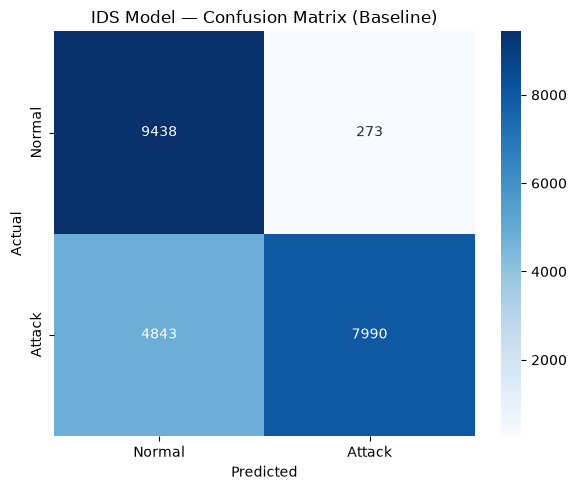

Saved to results/


In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Attack'],
            yticklabels=['Normal','Attack'])
plt.title('IDS Model — Confusion Matrix (Baseline)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../results/confusion_matrix_baseline.png', dpi=150)
plt.show()
print("Saved to results/")

In [10]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(rf_model, '../models/rf_ids_model.pkl')
joblib.dump(scaler,   '../models/scaler.pkl')

# Save processed data for Phase 3
np.save('../data/X_train.npy', X_train)
np.save('../data/X_test.npy',  X_test)
np.save('../data/y_train.npy', y_train)
np.save('../data/y_test.npy',  y_test)

print("Model saved to models/rf_ids_model.pkl")
print("Data saved to data ")

Model saved to models/rf_ids_model.pkl
Data saved to data 
